In [1]:
!pip install -q langchain langchain-openai langchain-community langgraph faiss-cpu

In [2]:
from google.colab import userdata
import os

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")

BASE_URL = "https://openrouter.ai/api/v1"

In [3]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

In [4]:
model="openai/gpt-oss-20b:free"

In [5]:
llm = ChatOpenAI(
    model=model,
    temperature=0,
    base_url=BASE_URL,
    api_key=OPENROUTER_API_KEY
)

In [6]:
embeddings = OpenAIEmbeddings(
    model="openai/text-embedding-3-small",
    base_url=BASE_URL,
    api_key=OPENROUTER_API_KEY
)

In [7]:
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

In [8]:
sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs.",
    "RAG stands for Retrieval-Augmented Generation and combines retrieval with generation.",
    "A vector database stores high-dimensional embeddings for semantic search.",
    "Agentic AI systems can reason, decide, retrieve information, and generate responses dynamically."
]

documents = [Document(page_content=text) for text in sample_texts]

vectorstore = FAISS.from_documents(documents, embeddings)
retriever = vectorstore.as_retriever(k=3)

In [9]:
def decide_retrieval(state: AgentState) -> AgentState:
    """
    Decide if retrieval is needed using an LLM.
    The LLM is asked to classify if the question is related to
    LangGraph, RAG, Vector DB, or Agentic AI.
    """
    question = state["question"]

    prompt = f"""
You are an AI assistant. Determine if the following question
is related to any of these topics: LangGraph, RAG, Vector DB, Agentic AI.

Question: "{question}"

Answer "YES" if retrieval is needed or "NO" if not.
"""

    response = llm.invoke(prompt)
    answer_text = response.content.strip().lower()

    needs_retrieval = answer_text.startswith("yes")
    print(needs_retrieval)
    return {**state, "needs_retrieval": needs_retrieval}


In [10]:
# def decide_retrieval(state: AgentState) -> AgentState:
#     question = state["question"]

#     retrieval_keywords = ["what", "how", "explain", "describe", "tell me"]

#     needs_retrieval = any(
#         keyword in question.lower() for keyword in retrieval_keywords
#     )

#     return {**state, "needs_retrieval": needs_retrieval}

In [11]:
def retrieve_documents(state: AgentState) -> AgentState:
    """
    Retrieve relevant documents based on the question
    """
    question = state["question"]
    documents = retriever.invoke(question)

    return {**state, "documents": documents}

In [12]:
def generate_answer(state: AgentState) -> AgentState:
    """
    Generate an answer using the retrieved documents or direct response
    """
    question = state["question"]
    documents = state.get("documents", [])

    if documents:
        # RAG approach: use documents as context
        context = "\n\n".join([doc.page_content for doc in documents])
        prompt = f"""Based on the following context, answer the question:

                      Context:
                      {context}

                      Question: {question}

                      Answer:"""
    else:
        # Direct response without retrieval
        prompt = f"Answer the following question: {question}"

    response = llm.invoke(prompt)
    answer = response.content

    return {**state, "answer": answer}

In [13]:
def should_retrieve(state: AgentState) -> str:
    """
    Determine the next step based on retrieval decision
    """
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

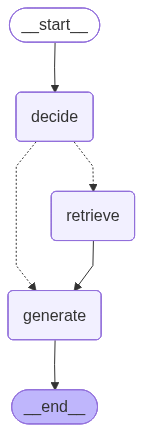

In [14]:
# Create the state graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("generate", generate_answer)

# Set entry point
workflow.set_entry_point("decide")

# Add conditional edges
workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve": "retrieve",
        "generate": "generate"
    }
)

# Add edges
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

# Compile the graph
app = workflow.compile()
app

In [15]:
def ask_question(question: str):
    """
    Helper function to ask a question and get an answer
    """
    initial_state = {
        "question": question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False
    }

    result = app.invoke(initial_state)
    return result

In [16]:
# Test with a question that should trigger retrieval
question1 = "What is LangGraph?"
result1 = ask_question(question1)
result1

True


{'question': 'What is LangGraph?',
 'documents': [Document(id='10b13584-366c-4707-8183-82c50bc5e5bb', metadata={}, page_content='LangGraph is a library for building stateful, multi-actor applications with LLMs.'),
  Document(id='fc78ebc3-9802-4dd8-adc4-84f11251b8e0', metadata={}, page_content='RAG stands for Retrieval-Augmented Generation and combines retrieval with generation.'),
  Document(id='0ecf0946-fbd8-491e-8e37-dbac8d8ed86c', metadata={}, page_content='A vector database stores high-dimensional embeddings for semantic search.'),
  Document(id='31d8cd24-4d94-4727-a07d-0c74429c131f', metadata={}, page_content='Agentic AI systems can reason, decide, retrieve information, and generate responses dynamically.')],
 'answer': 'LangGraph is a library designed to help developers build stateful, multi‑actor applications that leverage large language models (LLMs). It provides the tools and abstractions needed to orchestrate complex, agentic AI workflows—such as retrieval‑augmented generatio

In [17]:
# Test with another question
question2 = "How does RAG work?"
result2 = ask_question(question2)

print(f"Question: {question2}")
print(f"Retrieved documents: {len(result2['documents'])}")
print(f"Answer: {result2['answer']}")
print("\n" + "="*50 + "\n")

True
Question: How does RAG work?
Retrieved documents: 4
Answer: **Retrieval‑Augmented Generation (RAG) is a two‑step pipeline that lets a language model answer questions (or perform tasks) by first pulling in the most relevant external information and then generating a response that incorporates that information.**

1. **Query Encoding**  
   - The user’s question or prompt is turned into a dense vector (an embedding) using a language‑model encoder.

2. **Retrieval**  
   - The embedding is used to search a **vector database** (which stores high‑dimensional embeddings of documents, passages, or other knowledge sources).  
   - The database returns the top‑k most semantically similar items (e.g., paragraphs, articles, or knowledge‑base entries).

3. **Context Construction**  
   - The retrieved snippets are concatenated or otherwise formatted into a context that the LLM can read.  
   - Optionally, a small “retrieval policy” or “reasoning step” (as in agentic AI systems) decides which 

In [18]:
# Test with another question
question3 = "Where is the capital of France?"
result3 = ask_question(question3)

print(f"Question: {question3}")
print(f"Retrieved documents: {len(result3['documents'])}")
print(f"Answer: {result3['answer']}")
print("\n" + "="*50 + "\n")

False
Question: Where is the capital of France?
Retrieved documents: 0
Answer: The capital of France is **Paris**, located in the northern‑central part of the country along the Seine River.


